# 3 · Interpretable scorecard and untouched test evaluation

Unweighted logistic regression estimates the cohort's probability of TARGET=1 from train-selected WoE features. Fixed L2 regularization controls correlated features. Native logistic probabilities are retained; no calibration or model tuning uses test outcomes. The exported score represents score 600 at good:bad odds 50:1, with 20 points doubling those odds.

In [1]:
from pathlib import Path
import os
import sys
import json
import pandas as pd
from IPython.display import display, Image, Markdown

# The executor supplies these paths. Interactive runs default to local exports.
ROOT = Path(os.environ.get('HOME_CREDIT_PROJECT_ROOT', str(Path.cwd()))).resolve()
if not (ROOT / 'src' / 'analysis.py').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.analysis import ensure_analysis, load_features, eda_tables

INPUT = Path(os.environ.get('HOME_CREDIT_FEATURES', str(ROOT / 'exports' / 'applicant_features.csv')))
OUTPUT = Path(os.environ.get('HOME_CREDIT_ANALYSIS', str(ROOT / 'outputs' / 'analysis')))
STATUS = os.environ.get('HOME_CREDIT_DATA_STATUS', 'real')
LGD = float(os.environ.get('HOME_CREDIT_LGD', '0.45'))
SEED = int(os.environ.get('HOME_CREDIT_SEED', '42'))
manifest = ensure_analysis(INPUT, OUTPUT, data_status=STATUS, lgd=LGD, seed=SEED)
get_ipython().run_line_magic('matplotlib', 'inline')
display(Markdown(f'**Data status: {manifest["data_status"].upper()}**. '
    + ('Synthetic pipeline validation; no Home Credit conclusions.' if STATUS != 'real'
       else 'Computed from the supplied accepted-cohort export.')))


**Data status: REAL**. Computed from the supplied accepted-cohort export.

In [2]:
metrics = pd.read_csv(OUTPUT / 'model_metrics.csv')
odds = pd.read_csv(OUTPUT / 'odds_ratios.csv')
bands = pd.read_csv(OUTPUT / 'risk_bands.csv')
calibration = pd.read_csv(OUTPUT / 'calibration.csv')
display(metrics)
display(odds.sort_values('coefficient'))
display(Markdown(f'Intercept: **{manifest["intercept"]:.4f}**. Selected features: **{len(manifest["selected_features"])}**.'))

,split,applicants,bad_count,bad_rate,mean_predicted_pd,roc_auc,gini,ks,brier_score,log_loss
0,train,184506,14895,0.080729,0.080711,0.746914,0.493828,0.366216,0.068771,0.249897
1,validation,61502,4965,0.080729,0.080528,0.748768,0.497536,0.382181,0.068810,0.249798
2,test,61503,4965,0.080728,0.081137,0.751150,0.502299,0.370137,0.068480,0.248521


,feature,coefficient,odds_ratio,input_unit,coefficient_method
1,ext_source_2,-0.789626,0.454014,+1 WoE = +1 log(good_distribution/bad_distribu...,L2 regularized unweighted logistic; no Wald CI...
0,ext_source_3,-0.714540,0.489417,+1 WoE = +1 log(good_distribution/bad_distribu...,L2 regularized unweighted logistic; no Wald CI...
6,credit_to_goods,-0.631373,0.531861,+1 WoE = +1 log(good_distribution/bad_distribu...,L2 regularized unweighted logistic; no Wald CI...
9,installment_late_rate,-0.536085,0.585034,+1 WoE = +1 log(good_distribution/bad_distribu...,L2 regularized unweighted logistic; no Wald CI...
13,education_type,-0.532573,0.587092,+1 WoE = +1 log(good_distribution/bad_distribu...,L2 regularized unweighted logistic; no Wald CI...
18,gender,-0.506449,0.602632,+1 WoE = +1 log(good_distribution/bad_distribu...,L2 regularized unweighted logistic; no Wald CI...
2,ext_source_1,-0.505865,0.602984,+1 WoE = +1 log(good_distribution/bad_distribu...,L2 regularized unweighted logistic; no Wald CI...
3,employed_years,-0.448273,0.638730,+1 WoE = +1 log(good_distribution/bad_distribu...,L2 regularized unweighted logistic; no Wald CI...
7,bureau_credit_to_debt_ratio,-0.401254,0.669480,+1 WoE = +1 log(good_distribution/bad_distribu...,L2 regularized unweighted logistic; no Wald CI...
24,scheduled_installment_amount,-0.396353,0.672769,+1 WoE = +1 log(good_distribution/bad_distribu...,L2 regularized unweighted logistic; no Wald CI...


Intercept: **-2.4363**. Selected features: **25**.

## Interpret odds ratios correctly

Each odds ratio is exp(coefficient) for a **+1 WoE** change, conditional on the other included features. It is not a one-year age change or a one-currency-unit income change. The model uses regularized estimates, so the table does not present naive Wald confidence intervals. Coefficients can change sign with correlated predictors; they are not causal effects.

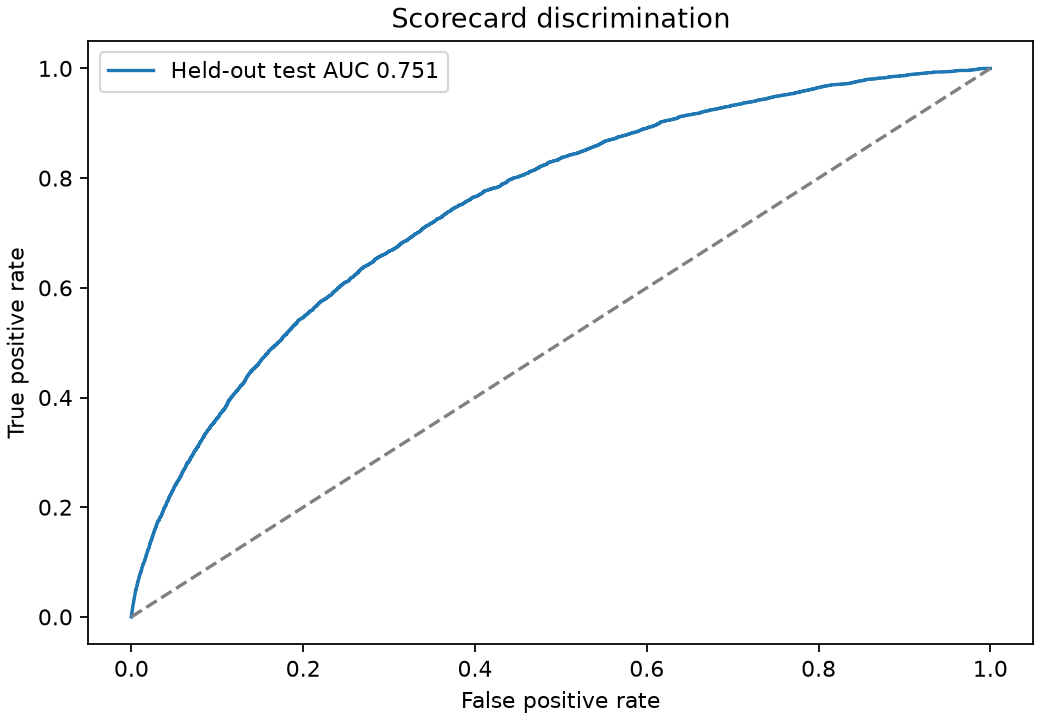

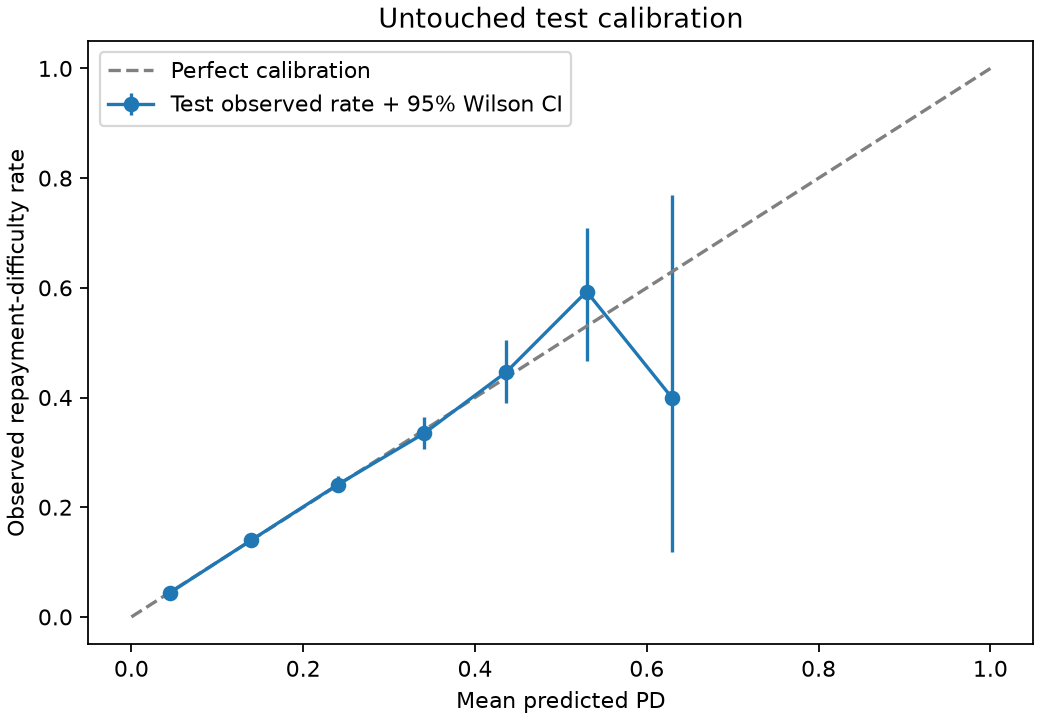

,split,bin,pd_lower,pd_upper,applicants,mean_predicted_pd,observed_bad_rate,bad_rate_ci_low,bad_rate_ci_high
20,test,1,0.0,0.1,44767,0.044746,0.044028,0.042166,0.045968
21,test,2,0.1,0.2,11981,0.138924,0.139304,0.133219,0.145620
22,test,3,0.2,0.3,3365,0.240349,0.241308,0.227151,0.256054
23,test,4,0.3,0.4,1037,0.340691,0.334619,0.306557,0.363902
24,test,5,0.4,0.5,289,0.436359,0.446367,0.390130,0.504011
25,test,6,0.5,0.6,59,0.529964,0.593220,0.465934,0.709110
26,test,7,0.6,0.7,5,0.629062,0.400000,0.117621,0.769276
27,test,8,0.7,0.8,0,NaN,NaN,NaN,NaN
28,test,9,0.8,0.9,0,NaN,NaN,NaN,NaN
29,test,10,0.9,1.0,0,NaN,NaN,NaN,NaN


In [3]:
display(Image(filename=str(OUTPUT / 'figures' / 'test_roc.png')))
display(Image(filename=str(OUTPUT / 'figures' / 'test_calibration.png')))
display(calibration[calibration.split == 'test'])

## Risk bands

Nine validation-prediction quantiles define ten increasing predicted-risk bands. Held-out observed rates are shown with Wilson intervals and may reverse. Test outcomes never trigger bin reordering, merging, recalibration or a refit. Tied predictions can produce empty bands. Higher risk_score means safer; higher risk_band means riskier.

,split,risk_band,applicants,bad_count,bad_rate,bad_rate_ci_low,bad_rate_ci_high,mean_predicted_pd,min_pd,max_pd,mean_risk_score,expected_loss,known_ead_count,missing_ead_count,expected_loss_coverage_rate,observed_rate_monotonicity_violation,compared_previous_nonempty_band
10,validation,1,6151,88,0.014307,0.011628,0.017592,0.012346,0.002196,0.017348,614.906989,2.560481e+07,6151,0,1.0,False,NaN
11,validation,2,6150,144,0.023415,0.019922,0.027502,0.021400,0.017350,0.025470,597.595791,4.061370e+07,6150,0,1.0,False,1.0
12,validation,3,6150,166,0.026992,0.023227,0.031347,0.029786,0.025471,0.034183,587.737466,5.280895e+07,6150,0,1.0,False,2.0
13,validation,4,6150,228,0.037073,0.032633,0.042092,0.038999,0.034185,0.044106,579.661349,6.777098e+07,6150,0,1.0,False,3.0
14,validation,5,6150,283,0.046016,0.041057,0.051542,0.049941,0.044106,0.056226,572.187554,8.304465e+07,6150,0,1.0,False,4.0
15,validation,6,6150,365,0.059350,0.053715,0.065534,0.063609,0.056229,0.071544,564.787615,1.024313e+08,6150,0,1.0,False,5.0
16,validation,7,6150,482,0.078374,0.071917,0.085357,0.081348,0.071545,0.092448,557.148769,1.255547e+08,6150,0,1.0,False,6.0
17,validation,8,6150,719,0.116911,0.109118,0.125181,0.106595,0.092451,0.122860,548.563089,1.558768e+08,6150,0,1.0,False,7.0
18,validation,9,6150,918,0.149268,0.140581,0.158393,0.146843,0.122865,0.177186,538.048883,2.077772e+08,6150,0,1.0,False,8.0
19,validation,10,6151,1572,0.255568,0.244823,0.266619,0.254398,0.177187,0.678835,518.986249,3.331674e+08,6151,0,1.0,False,9.0


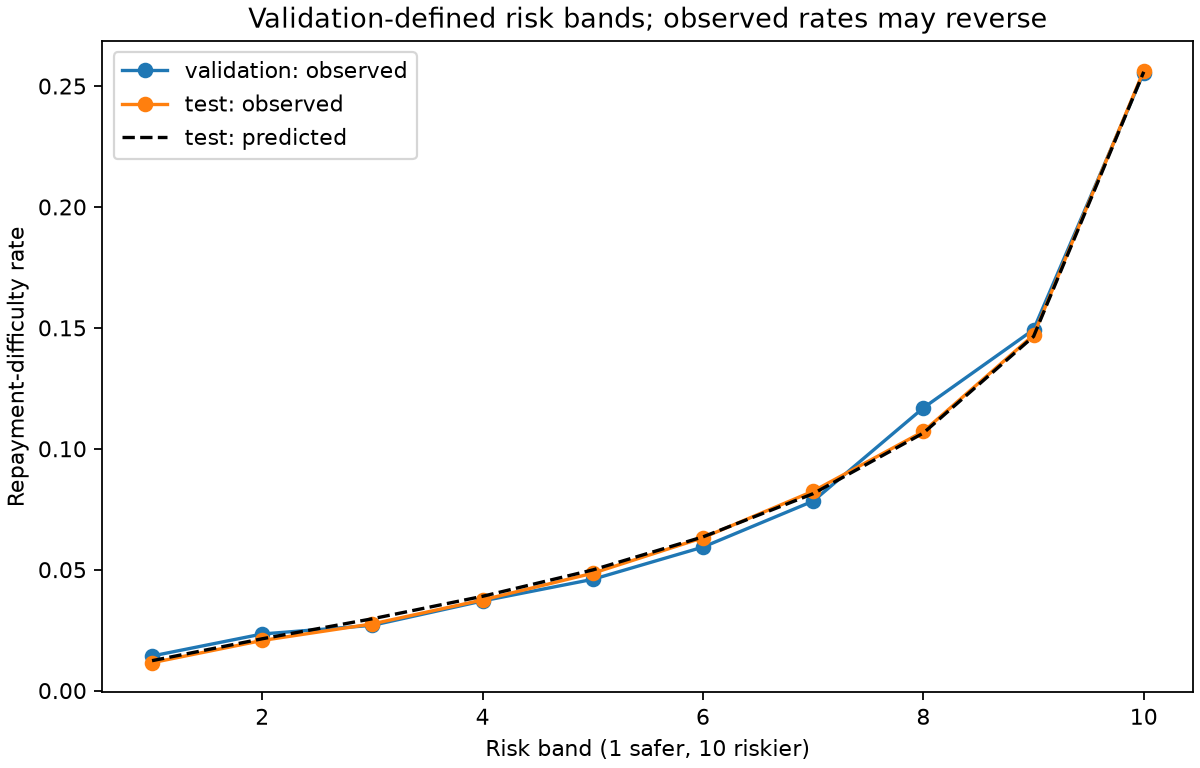

Observed nonempty-band monotonicity reversals: **0**.

Validation-defined PD boundaries: [0.017348372464500387, 0.025470285426694588, 0.03418387509381307, 0.044106300023155603, 0.05622779262769631, 0.07154458614855366, 0.09245029095026439, 0.12286396242537384, 0.17718710063678203]


In [4]:
display(bands[bands.split.isin(['validation', 'test'])])
display(Image(filename=str(OUTPUT / 'figures' / 'risk_bands.png')))
violations = bands[bands.split.isin(['validation', 'test']) & bands.observed_rate_monotonicity_violation]
display(Markdown(f'Observed nonempty-band monotonicity reversals: **{len(violations)}**.'))
print('Validation-defined PD boundaries:', manifest['band_boundaries'])

## Validation limits

The 60/20/20 split is stratified and at applicant level, with no duplicate applicants. It is random because no usable calendar date of the current application is provided; it does not establish temporal performance. AUC, KS, Gini and Brier scores are point estimates for this cohort. Inspect sample sizes and calibration before considering any deployment.